In [1]:
# hi_ref_demo.py
import jax
import jax.numpy as jnp
from ott.geometry import pointcloud                    # coût euclidien
from ott.solvers.linear import sinkhorn_lr             # OT bas‑rang
import numpy as np

# ---------- données jouet : 8 points 2D -------------------------------
key = jax.random.PRNGKey(0)
x = jax.random.uniform(key, (8, 2))          # source
y = x[:, ::-1] + jnp.array([0.2, -0.2])      # cible = même forme, petit décalage

# ---------- sous‑routine low‑rank OT  ----------------------------------
def low_rank_ot(x_block: jnp.ndarray,
                y_block: jnp.ndarray,
                rank: int = 2):
    """Résout un OT de rang=2 avec g uniforme, renvoie Q,R,g."""
    # géométrie : coût euclidien
    geom = pointcloud.PointCloud(x_block, y_block)
    # masses uniformes par défaut (a = b = 1/|bloc|)
    out = sinkhorn_lr.sinkhorn_lr(geom,
                                  rank=rank,
                                  epsilon=1e-1,            # régularisation
                                  g_init="uniform",        # g = (1/rank,…)
                                  max_iterations=500,
                                  jit=True)
    # out.q, out.r, out.g contiennent Q,R,g (déjà normalisés)
    return out.q, out.r, out.g

# ---------- HiRef (version récursive simple) ---------------------------
def hiref(x_block, y_block, rank=2, base_size=1, depth=0):
    n = x_block.shape[0]
    if n <= base_size:
        # bloc de taille 1 : retourne l’indice final
        return [(int(depth), int(depth))]   # ici on retourne juste positions internes

    # ====  étape low‑rank  ============================================
    Q, R, g = low_rank_ot(x_block, y_block, rank=rank)

    # étiquettes du bloc = argmax par ligne
    lab_x = jnp.argmax(Q, axis=1)
    lab_y = jnp.argmax(R, axis=1)

    # chaque couleur définit un sous‑bloc
    pairs = []
    for z in range(rank):
        x_sub = x_block[lab_x == z]
        y_sub = y_block[lab_y == z]
        # récursion (profondeur+1 pour debug)
        pairs.extend(hiref(x_sub, y_sub, rank, base_size, depth + 1))
    return pairs


# ----------------------------------------------------------------------
if __name__ == "__main__":
    # on lance HiRef
    final_pairs = hiref(x, y, rank=2, base_size=1)
    print("Paires finales (ordre interne) :", final_pairs)


ModuleNotFoundError: No module named 'jax'

In [15]:
import ott
print(ott.__version__)

0.5.0


In [17]:
import pkg_resources
print(pkg_resources.get_distribution("ott-jax").version)


0.5.0


/tmp/ipykernel_18693/3580218849.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [18]:
import ott.solvers.linear.sinkhorn_lr as lr
print("Module file:", lr.__file__)
print("Docstring:", lr.LRSinkhorn.__doc__.splitlines()[0])

Module file: /opt/conda/lib/python3.12/site-packages/ott/solvers/linear/sinkhorn_lr.py
Docstring: Low-Rank Sinkhorn solver for linear reg-OT problems.


In [19]:
# hi_ref_demo.py
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn, sinkhorn_lr
from ott.tools import plot

In [20]:
print(ott.__version__)

0.5.0


In [3]:
# ---------- données jouet : 8 points 2D -------------------------------
key = jax.random.PRNGKey(0)
x = jax.random.uniform(key, (8, 2))          # source
y = x[:, ::-1] + jnp.array([0.2, -0.2])      # cible = même forme, petit décalage

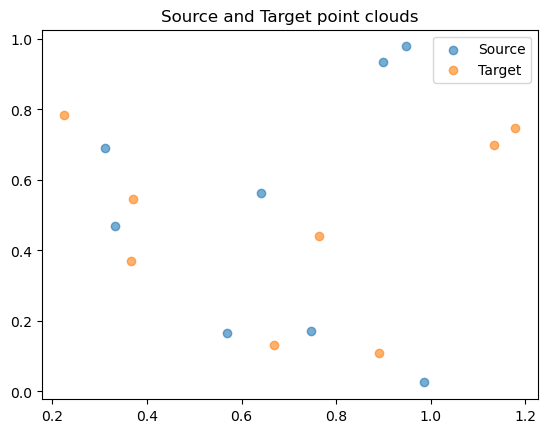

In [4]:
plt.scatter(x[:, 0], x[:, 1], label="Source", alpha=0.6)
plt.scatter(y[:, 0], y[:, 1], label="Target", alpha=0.6)
plt.legend()
plt.title("Source and Target point clouds")
plt.show()

In [12]:
# ---------- sous‑routine low‑rank OT  ----------------------------------
def low_rank_ot(x_block: jnp.ndarray,
                y_block: jnp.ndarray,
                rank: int = 2):
    """Résout un OT de rang=2 avec g uniforme, renvoie Q,R,g."""

    # build OT problem
    geom    = pointcloud.PointCloud(x_block, y_block) # géométrie : coût euclidien
    a       = jnp.ones(x_block.shape[0]) / x_block.shape[0] # poids uniforme
    ot_prob = linear_problem.LinearProblem(geom, a, a)


    # masses uniformes par défaut (a = b = 1/|bloc|)
    a = 1/x_block.shape[0]
    b = a
    ot_prob = linear_problem.LinearProblem(geom, a, b)

    # choose and pass a KMeans initializer instance
    initializer = KMeansInitializer(rank=rank,
                                    min_iterations=50,
                                    max_iterations=200)
    solver = jax.jit(LRSinkhorn(rank=rank,
                                initializer=initializer))
    ot_lr = solver(ot_prob)
    
    # out.q, out.r, out.g contiennent Q,R,g (déjà normalisés)
    return ot_lr

In [ ]:
# geom = pointcloud.PointCloud(x, y, epsilon=0.1)
# ot_prob = linear_problem.LinearProblem(geom, a, b)
# costs = []
# ranks = [15, 20, 35, 50, 100]
# for rank in ranks:
#     solver = jax.jit(sinkhorn_lr.LRSinkhorn(rank=rank, initializer="k-means"))
#     ot_lr = solver(ot_prob)
#     costs.append(ot_lr.reg_ot_cost)

NameError: name 'a' is not defined

In [6]:
# ---------- HiRef (version récursive simple) ---------------------------
def hiref(x_block, y_block, rank=2, base_size=1, depth=0):
    n = x_block.shape[0]
    if n <= base_size:
        # bloc de taille 1 : retourne l’indice final
        return [(int(depth), int(depth))]   # ici on retourne juste positions internes

    # ====  étape low‑rank  ============================================
    Q, R, g = low_rank_ot(x_block, y_block, rank=rank)

    # étiquettes du bloc = argmax par ligne
    lab_x = jnp.argmax(Q, axis=1)
    lab_y = jnp.argmax(R, axis=1)

    # chaque couleur définit un sous‑bloc
    pairs = []
    for z in range(rank):
        x_sub = x_block[lab_x == z]
        y_sub = y_block[lab_y == z]
        # récursion (profondeur+1 pour debug)
        pairs.extend(hiref(x_sub, y_sub, rank, base_size, depth + 1))
    return pairs

In [7]:
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # on lance HiRef
    final_pairs = hiref(x, y, rank=2, base_size=1)
    print("Paires finales (ordre interne) :", final_pairs)

TypeError: 'str' object is not callable

# 1ère partition 
- 2 blocs de 4 points 
- Low rank r=2 
- g uniforme

In [29]:
import jax
import jax.numpy as jnp
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn
from ott.initializers.linear.initializers_lr import KMeansInitializer

def low_rank_ot(x_block: jnp.ndarray,
                y_block: jnp.ndarray,
                rank: int = 2):
    """Résout un OT de rang `rank` avec g uniforme, renvoie Q, R, g."""
    # Geometry: Euclidean cost
    geom = pointcloud.PointCloud(x_block, y_block)

    # Masses uniformes (a = b = 1/|bloc|)
    n = x_block.shape[0]
    a = jnp.ones(n) / n
    b = a

    # Définir le problème OT linéaire
    ot_prob = linear_problem.LinearProblem(geom, a, b)

    # Initialiseur k-means pour facteurs Q, R
    initializer = KMeansInitializer(rank=rank,
                                    min_iterations=50,
                                    max_iterations=200)

    # Solver low-rank Sinkhorn compilé via JAX
    solver = jax.jit(LRSinkhorn(rank=rank,
                                initializer=initializer))
    ot_lr = solver(ot_prob)

    # ot_lr.q, ot_lr.r, ot_lr.g contiennent Q, R, g normalisés
    return ot_lr.q, ot_lr.r, ot_lr.g


In [30]:
low_rank_ot(x, y, rank=2)

(Array([[0.0000000e+00, 1.2504958e-01],
        [0.0000000e+00, 1.2504958e-01],
        [1.2491736e-01, 0.0000000e+00],
        [0.0000000e+00, 1.2504958e-01],
        [1.2491733e-01, 0.0000000e+00],
        [1.2491736e-01, 0.0000000e+00],
        [1.6541816e-17, 1.2504958e-01],
        [0.0000000e+00, 1.2504958e-01]], dtype=float32),
 Array([[1.37303127e-29, 1.24950536e-01],
        [1.25082642e-01, 0.00000000e+00],
        [2.30156164e-22, 1.24950476e-01],
        [1.25082612e-01, 0.00000000e+00],
        [0.00000000e+00, 1.24950536e-01],
        [0.00000000e+00, 1.24950476e-01],
        [1.24586761e-01, 4.95340442e-04],
        [1.13079109e-22, 1.24950476e-01]], dtype=float32),
 Array([0.37475204, 0.6252479 ], dtype=float32))